In [1]:
import numpy as np
import os
import cvxpy as cp

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from scipy.spatial import ConvexHull


In [29]:
# load mode parameter from data
lure_params_path = os.path.join('datasets', 'Duffing', 'lure_model_params_scaled.npz')
theta = np.load(lure_params_path)
# print(f'Saved Lur\'e model parameters to {lure_params_path}')
A = theta['A']
B = theta['B']
C = theta['C']
B2 = theta['B2']
C2 = theta['C2']
D = theta['D']
D12 = theta['D12']
D21 = theta['D21']
TS = float(theta['TS'])
nz = int(theta['nz'])
nx = int(theta['nx'])
nd = int(theta['nu'])
ne = int(theta['ny'])

In [30]:
print(f'A: {A} \n B: {B}\n C: {C}\n D: {D}')
print(f'B2: {B2}\n C2: {C2}\n D12: {D12}\n D21: {D21}')



A: [[ 1.     0.05 ]
 [-0.05   0.985]] 
 B: [[0.       ]
 [0.0039662]]
 C: [[6.58489445 0.        ]]
 D: [[0.]]
B2: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.00556457 0.01755953 0.04252413 0.07508705 0.11689463 0.16913675
  0.22928246 0.30034822 0.37948621 0.46870539 0.56760693 0.67407641
  0.79379072 0.91629349 1.05828194 1.19480956 1.36282576 1.50314181
  1.73255    0.        ]]
 C2: [[4.         0.        ]
 [2.         0.        ]
 [1.33333333 0.        ]
 [1.         0.        ]
 [0.8        0.        ]
 [0.66666667 0.        ]
 [0.57142857 0.        ]
 [0.5        0.        ]
 [0.44444444 0.        ]
 [0.4        0.        ]
 [0.36363636 0.        ]
 [0.33333333 0.        ]
 [0.30769231 0.        ]
 [0.28571429 0.        ]
 [0.26666667 0.        ]
 [0.25       0.        ]
 [0.23529412 0.        ]
 [0.22222222 0.     

In [4]:
# alpha = 1-1e-3
# alpha = 0.994
alpha = 1-1e-3


In [ ]:
eps = 1e-6

# Decision variables
P = cp.Variable((nx, nx), symmetric=True)
L = cp.Variable((nz, nx))
m = cp.Variable((nz, 1))
M = cp.diag(m)

# S_hat for optimizing s
S_hat = cp.Variable((1, 1))

# Constraints
constraints = []

# Multiplier constraints: m(i) >= eps for all i
for i in range(nz):
    constraints.append(m[i, 0] >= eps)

# Main LMI: F <= -eps*I
F = cp.bmat(
    [
        [-(alpha**2) * P, np.zeros((nx, nd)), P @ C2.T + L.T, P @ A.T],
        [np.zeros((nd, nx)), -np.eye(nd), D21.T, B.T],
        [C2 @ P + L, D21, -2 * M, M @ B2.T],
        [A @ P, B, B2 @ M, -P],
    ]
)
nF = F.shape[0]
constraints.append(F << -eps * np.eye(nF))

# Locality constraints: [S_hat, li; li', P] >= eps*I for each row of L
for i in range(nz):
    li = L[i, :].reshape((1, -1), order="C")
    locality_lmi = cp.bmat([[S_hat, li], [li.T, P]])
    constraints.append(locality_lmi >> eps * np.eye(nx + 1))

# P positive definite
# constraints.append(P >> eps * np.eye(nx))


# Objective
objective = cp.Minimize(S_hat)

# Solve
problem = cp.Problem(objective, constraints)
print(f"Solving SDP with {len(constraints)} constraints using MOSEK...")

problem.solve(solver=cp.MOSEK, verbose=False)
print(f"SDP status: {problem.status}")




        

Solving SDP with 41 constraints using MOSEK...
SDP status: optimal


In [6]:
Pinv = np.linalg.inv(P.value)
H = L.value @ Pinv
X = Pinv
s = np.sqrt(1/S_hat.value)
delta2 = s**2*(1-alpha**2)

In [7]:
print(f'delta={delta2}, \t s={s}')



delta=[[0.30896352]], 	 s=[[12.43217761]]


In [8]:
# import matplotlib.pyplot as plt
N = 100
xs = np.linspace(0, (N-1)*TS, N)
u = np.exp(-xs*0.1)

# fig, ax = plt.subplots(figsize=(10,5))
# ax.plot(xs, u)
# plt.show()

sum_u = 0
for u_k in u[:-1]:
    u_k = np.array([[u_k]])
    sum_u += u_k.T @ u_k

print(f'sum_u: {sum_u[0,0]:.5f}, 2*(1-alpha**(2*N)): {s[0,0]**2*(1-alpha**(2*N)):.5f}')


sum_u: 63.15707, 2*(1-alpha**(2*N)): 28.02946


In [9]:
# Find vertices of polytope |Hx|_∞ < 1
def find_polytope_vertices_2d(H, tol=1e-6):
    """Find vertices of the polytope |Hx|_∞ < 1 in 2D"""
    vertices = []
    nz = H.shape[0]
    
    # Try all pairs of constraints as equalities
    for i in range(nz):
        for j in range(nz):
            for h_val_i in [1, -1]:
                for h_val_j in [1, -1]:
                    # Solve: H[i] @ x = h_val_i and H[j] @ x = h_val_j
                    A = np.array([H[i, :], H[j, :]])
                    b = np.array([h_val_i, h_val_j], dtype=float)
                    
                    try:
                        x = np.linalg.solve(A, b)
                        # Check if point satisfies all constraints |H_k @ x| <= 1
                        if np.all(np.abs(H @ x) <= 1.0 + tol):
                            vertices.append(x)
                    except np.linalg.LinAlgError:
                        pass
    
    if len(vertices) == 0:
        return np.array([])
    
    # Remove duplicates
    vertices = np.array(vertices)
    vertices = np.unique(np.round(vertices, decimals=8), axis=0)
    
    return vertices

In [10]:
def dzn(z):
    """Scalar deadzone: max(|z| - 1, 0) * sign(z)."""
    return np.maximum(np.abs(z) - 1, 0.0) * np.sign(z)

def lure_step(x, u, psi=dzn):
    u = np.asarray(u).reshape(-1)
    z = C2 @ x + D21 @ u
    w = psi(z)
    y_hat = C @ x + D @ u + D12 @ w
    x = A @ x + B @ u + B2 @ w
    return y_hat, x

def simulate_lure(x0, u_seq, psi=dzn, diverge_thresh=50.0, safety_filter = True, max_input = False):
    X = [x0.copy()]
    Y = []
    u_n = []
    diverged = False
    for u in u_seq:
        u_max = np.sqrt(s**2 - alpha**2 * X[-1].reshape((1,-1)) @ Pinv @ X[-1].reshape((-1,1)))
        if safety_filter and (u_max < u ):
            # print(f'u={u.squeeze():.2f}, u_max = {u_max.squeeze():.2f}')
            u = u_max  
        if max_input:
            u = u_max
        y_hat, x = lure_step(X[-1], u, psi=psi)
        if np.any(np.abs(x)>diverge_thresh):
            diverged = True
            break
        X.append(x)
        Y.append(y_hat)
        u_n.append(float(u.squeeze()))
        # print(u_n)
    return np.array(X), np.array(Y).reshape(-1), diverged, np.array(u_n)

# load data

In [11]:
import pandas as pd
# load all csv training data from ./datasets/Duffing/train/ folder

# dir = os.path.join('datasets', 'Duffing', 'train 11.33.24')
dir = os.path.join('datasets', 'Duffing', 'train')
csv_files = [f for f in os.listdir(dir) if f.endswith('.csv')]
print(f'Found {len(csv_files)} CSV files in {dir}:')
u_names = ['u']
x_names = ['q', 'q_dot']
y_names = ['q']
# load x, y, u columns from each csv file using pandas

xs = []
ys = []
us = []
for f in csv_files:
    data = pd.read_csv(os.path.join(dir, f))
    x_data = data[x_names]
    y_data = data[y_names]
    u_data = data[u_names]
    xs.append(x_data)
    ys.append(y_data)
    us.append(u_data)

u_std = np.std(np.concatenate(us, axis=0))
X_std = np.std(np.concatenate(xs, axis=0), axis=0)
y_std = np.std(np.concatenate(ys, axis=0))

u_n = np.concatenate(us, axis=0) * 1/u_std
y_n = np.concatenate(ys, axis=0) * 1/y_std

print(f'Loaded data from {len(csv_files)} CSV files. Each file has {xs[0].shape[0]} samples.')

print(f'u_std: {u_std:.5f}, X_std: {X_std}, y_std: {y_std:.5f}')
print(f'u_n_std: {np.std(u_n):.5f}, y_n_std: {np.std(y_n):.5f}')


Found 30 CSV files in datasets/Duffing/train:
Loaded data from 30 CSV files. Each file has 4000 samples.
u_std: 0.08103, X_std: [0.1578152  0.13563424], y_std: 0.15782
u_n_std: 1.00000, y_n_std: 1.00000


# simulate worst case input trajectory

In [12]:
N2 = 50
u = np.zeros((N2, 1))
x0 = np.array([-0.1, -0.1])
print(f'{x0.reshape((1,-1)) @ Pinv @ x0.reshape((-1,1)) < s**2}')

X_max, y_hat_max, _, u_max_n = simulate_lure(x0, u, max_input=True)

u_max = u_max_n * u_std

[[ True]]


In [13]:
xs[-1]

,q,q_dot
0,-0.223873,0.224968
1,-0.212542,0.228151
2,-0.201081,0.230214
3,-0.189542,0.231263
4,-0.177973,0.231397
...,...,...
3995,-0.027609,0.100460
3996,-0.022818,0.091128
3997,-0.018500,0.081585
3998,-0.014664,0.071872


In [14]:
xs.append(pd.DataFrame(X_max, columns=x_names))
ys.append(pd.DataFrame(y_hat_max, columns=y_names))
us.append(pd.DataFrame(u_max, columns=u_names))

In [15]:
s**2 - alpha**(2*10)*(xs[0].to_numpy()[0,:].reshape(1,-1) @ X @ xs[0].to_numpy()[0,:].reshape(-1,1))

array([[118.73737058]])

In [16]:
alpha

0.999

In [17]:
for idx, (u_i, X_i) in enumerate(zip(us, xs)):
    u_i_n = (u_i.to_numpy() / u_std)
    X_i = X_i.to_numpy()
    T = len(u_i_n)
    x0 = X_i[0, :]
    max_u = np.max((u_i_n**2))
    norm_sum = np.sum(u_i_n**2)
    gamma_1 = s**2 * (1-alpha**(2*T))
    x0s = (x0.reshape(1,-1) @ X @ x0.reshape(-1,1))
    gamma_2 = s**2 - alpha**(2*T) * x0s
    delta2 = s**2*(1-alpha**2)
    if x0s[0,0] < s**2 :
        print(f'{idx}: max_u= {max_u:.5f}, delta^2= {delta2[0,0]:.5f}, gamma = {gamma_1[0,0]:.2f}, sum_u {norm_sum:.5f}, sum_u < s^2 - alpha^(2*T) * x0.T @ X @ x0?: \t{norm_sum < gamma_2[0,0]}')
    else:
        print(f'{idx}: x0.T @ X @ x0 < s^2: {x0s[0,0] < s**2}')

0: max_u= 1.31552, delta^2= 0.30896, gamma = 154.51, sum_u 389.24813, sum_u < s^2 - alpha^(2*T) * x0.T @ X @ x0?: 	False
1: max_u= 14.37780, delta^2= 0.30896, gamma = 154.51, sum_u 6971.46115, sum_u < s^2 - alpha^(2*T) * x0.T @ X @ x0?: 	False
2: x0.T @ X @ x0 < s^2: [[False]]
3: max_u= 24.26211, delta^2= 0.30896, gamma = 154.51, sum_u 11528.90287, sum_u < s^2 - alpha^(2*T) * x0.T @ X @ x0?: 	False
4: max_u= 0.16918, delta^2= 0.30896, gamma = 154.51, sum_u 39.34965, sum_u < s^2 - alpha^(2*T) * x0.T @ X @ x0?: 	True
5: max_u= 27.71171, delta^2= 0.30896, gamma = 154.51, sum_u 10432.38748, sum_u < s^2 - alpha^(2*T) * x0.T @ X @ x0?: 	False
6: max_u= 19.96996, delta^2= 0.30896, gamma = 154.51, sum_u 7736.54404, sum_u < s^2 - alpha^(2*T) * x0.T @ X @ x0?: 	False
7: x0.T @ X @ x0 < s^2: [[False]]
8: max_u= 17.79242, delta^2= 0.30896, gamma = 154.51, sum_u 5327.20491, sum_u < s^2 - alpha^(2*T) * x0.T @ X @ x0?: 	False
9: max_u= 4.68104, delta^2= 0.30896, gamma = 154.51, sum_u 1835.83803, sum_

# Simulation examples

## Verification of theoretical results with simulation examples

This section verifies two theoretical results:

**Corollary 1 (One-step ahead):** Given $x_k$ satisfying $(x_k)^T X x_k \leq s^2$, the state at the next time step $x_{k+1}$ remains inside $\mathcal{X} = \mathcal{E}(X/s^2)$ if:
$$
(d_k)^T d_k \leq s^2 - \alpha^2 V(x_k)
$$

**Theorem 2 (input bound on entire trajectory):** Given initial state $(x_0)^T X x_0 \leq s^2$, if the input sequence satisfies:
$$
\sum_{\tau=0}^{k-1} \alpha^{2(k-1-\tau)} (d_\tau)^T d_\tau \leq s^2 - \alpha^{2k} (x_0)^T X x_0 \quad \forall k \geq 1
$$
then the state $x_k$ is certified never to leave the ellipsoid $\mathcal{X} = \mathcal{E}(X/s^2)$ for all $k \geq 0$.

In [18]:
# Select specific trajectory indices for detailed analysis
# These indices are hand-picked to show different behaviors
idxs = [0, 6, 17, 30, 26, 39]

# Create mesh grid for visualizing the ellipsoid
n_points = 300
bound = 1.2
x1 = np.linspace(-bound, bound, n_points)
x2 = np.linspace(-bound, bound, n_points)
X1, X2 = np.meshgrid(x1, x2)

# Compute quadratic form x^T (X/s^2) x for each point to define the ellipsoid
X_scaled = X / (s ** 2)
quad_form = np.zeros_like(X1)
for i in range(n_points):
    for j in range(n_points):
        x_pt = np.array([X1[i, j], X2[i, j]])
        quad_form[i, j] = x_pt @ X_scaled @ x_pt

# Find vertices of the polytope |Hx|_∞ ≤ 1 for visualization
vertices = find_polytope_vertices_2d(H)

In [19]:
u_std

0.08102981267862445

/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_31601/2722873929.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  refined_bound = float(s**2) - alpha**(2 * horizon) * initial_lyap_value
/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_31601/2722873929.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  initial_inside_ellipsoid = (initial_lyap_value <= float(s**2))
/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_31601/717210932.py:19: RuntimeWarning: invalid value encountered in sqrt
  u_max = np.sqrt(s**2 - alpha**2 * X[-1].reshape((1,-1)) @ Pinv @ X[-1].reshape((-1,1)))


Traj 0: ✗ Input bound violated (Theorem)
  ∑ d² = 389.24813 > s² - α^{2T} V(x_0) = 154.54683
  Weighted ∑ = 35.15429
Traj 6: ✗ Input bound violated (Theorem)
  ∑ d² = 7736.54404 > s² - α^{2T} V(x_0) = 154.51131
  Weighted ∑ = 432.67281
Traj 17: ✗ x_0 outside ellipsoid
  x_0^	op X x_0 = 230.29580 > s² = 154.55904
Traj 26: ✗ Input bound violated (Theorem)
  ∑ d² = 3177.86312 > s² - α^{2T} V(x_0) = 154.51506
  Weighted ∑ = 213.54254


/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_31601/2722873929.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f'  x_0^\top X x_0 = {initial_lyap_value:.5f} > s² = {float(s**2):.5f}')


Traj 30: ✗ Input bound violated (Theorem)
  ∑ d² = 1557.24557 > s² - α^{2T} V(x_0) = 142.30546
  Weighted ∑ = 1429.48944
Delta: 0.30896, s^2: 154.55904


/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_31601/2722873929.py:198: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax_inputs.axhline(y=float(s**2), color='black', linestyle='-',
/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_31601/2722873929.py:200: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax_inputs.axhline(y=float(delta2), color='grey', alpha=0.8, linewidth=2, label=r'$\delta^2$')
/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_31601/2722873929.py:201: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element

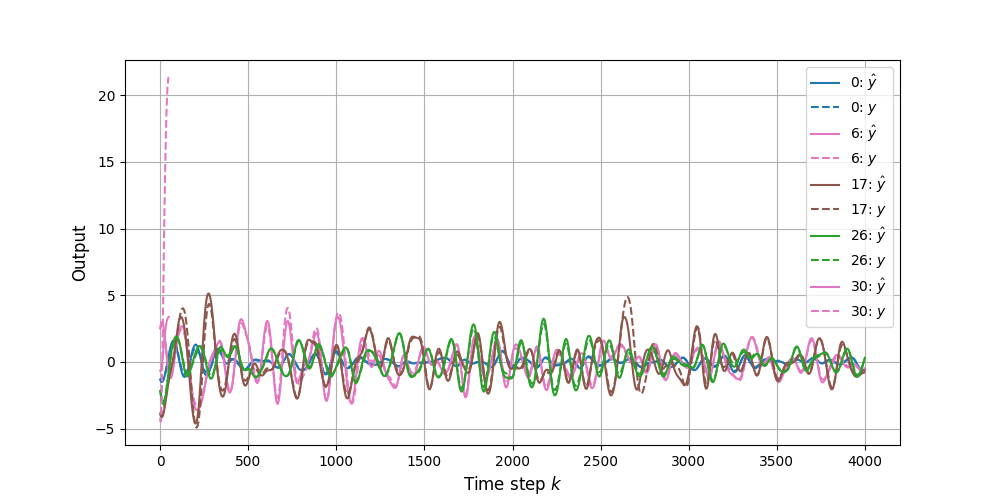

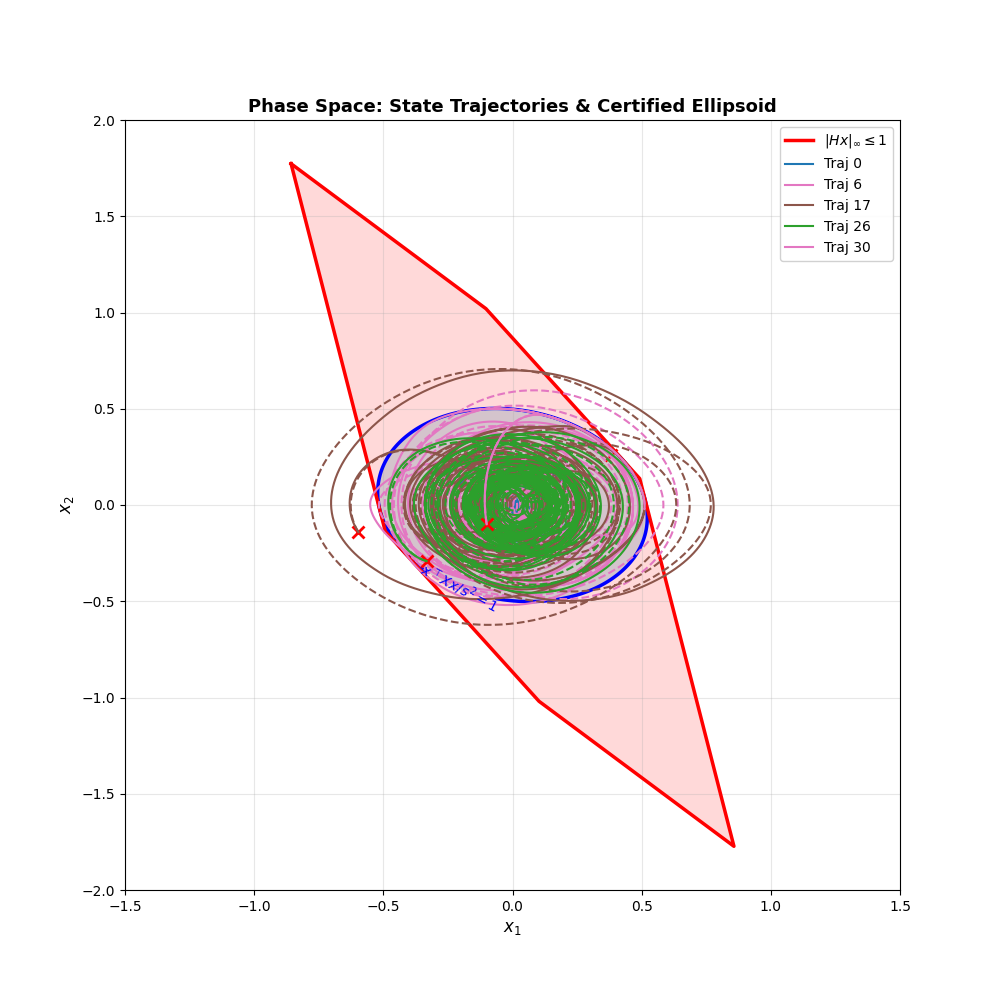

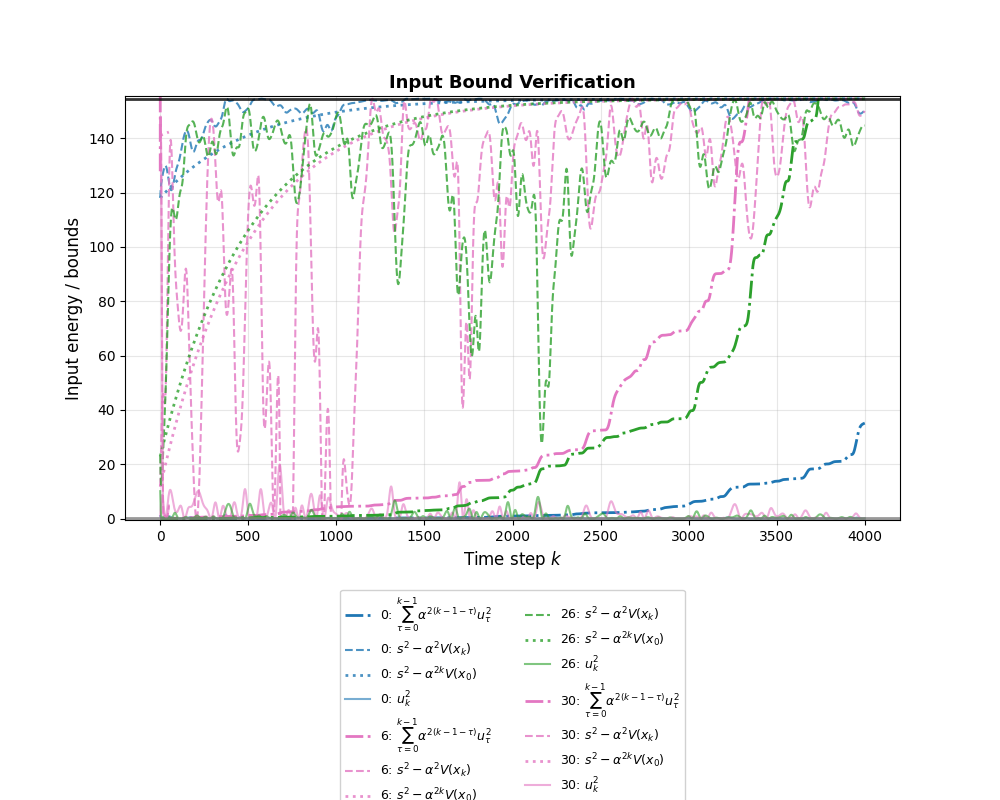

In [20]:
# =================================================================
# Main Verification: Corollary & Theorem with Simulation Data
# =================================================================


# Enable matplotlib's built-in math rendering (no LaTeX installation needed)
# plt.rcParams['text.usetex'] = False  # Use mathtext instead of LaTeX
# plt.rcParams['font.family'] = 'DejaVu Sans'
# plt.rcParams['mathtext.fontset'] = 'dejavusans'


# Hand-picked trajectory indices to demonstrate different behaviors
selected_trajectories = [0, 6, 17, 30, 33, 26, 48]

# Create mesh grid for visualizing the ellipsoid
grid_points = 300
plot_bound = 1.2
x1_grid = np.linspace(-plot_bound, plot_bound, grid_points)
x2_grid = np.linspace(-plot_bound, plot_bound, grid_points)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)

# Compute the quadratic form x^T (X/s²) x at each grid point
# This defines the ellipsoid boundary where the value equals 1
X_normalized = X / (s ** 2)
lyapunov_surface = np.zeros_like(X1_mesh)
for i in range(grid_points):
    for j in range(grid_points):
        x_pt = np.array([X1_mesh[i, j], X2_mesh[i, j]])
        lyapunov_surface[i, j] = x_pt @ X_normalized @ x_pt

# Find vertices of polytope |Hx|_∞ ≤ 1 (sector condition)
polytope_vertices = find_polytope_vertices_2d(H)

# Create figures for phase space and input verification
fig_phase, ax_phase = plt.subplots(figsize=(10, 10))
fig_inputs, ax_inputs = plt.subplots(figsize=(10, 8))
fig_outputs, ax_outputs = plt.subplots(figsize=(10,5))

# -----------------------------------------------------------------
# Plot 1: Phase Space - Certified Ellipsoid
# -----------------------------------------------------------------
ellipsoid_levels = [0, 1]
ax_phase.contourf(X1_mesh, X2_mesh, lyapunov_surface, 
                   levels=ellipsoid_levels, colors=['lightblue'], alpha=0.6)
ellipsoid_boundary = ax_phase.contour(X1_mesh, X2_mesh, lyapunov_surface, 
                                       levels=[1], colors=['blue'], linewidths=2.5)
ax_phase.clabel(ellipsoid_boundary, inline=True, fontsize=10, 
                fmt=r'$x^\top X x / s^2 = 1$')

# Plot polytope |Hx|_∞ ≤ 1
if len(polytope_vertices) > 0:
    hull = ConvexHull(polytope_vertices)
    poly_verts_sorted = polytope_vertices[hull.vertices]
    poly_closed = np.vstack([poly_verts_sorted, poly_verts_sorted[0]])  # Close polygon
    ax_phase.plot(poly_closed[:, 0], poly_closed[:, 1], 
                  'r-', linewidth=2.5, label=r'$|Hx|_\infty \leq 1$')
    ax_phase.fill(poly_verts_sorted[:, 0], poly_verts_sorted[:, 1], 
                  'red', alpha=0.15)

# -----------------------------------------------------------------
# Main Loop: Analyze Each Selected Trajectory
# -----------------------------------------------------------------
for traj_idx, (input_traj, state_traj, output_traj) in enumerate(zip(us, xs, ys)):
    if traj_idx not in selected_trajectories:
        continue
    
    # Extract and prepare data
    horizon = len(input_traj)  # T = trajectory length
    u_n = (input_traj.to_numpy() / u_std)  # d_k = u_k / σ_u
    y_n = (output_traj.to_numpy() / y_std)
    # y_n = output_traj.to_numpy()
    x = state_traj.to_numpy()  # [x_0, x_1, ..., x_{T-1}]
    x0 = x[0, :]  # x_0

    # simulate lure system
    X_sim, y_hat_n, _, u_sim_n = simulate_lure(x0, u_n)

    
    # Compute key quantities
    total_input_energy = float(np.sum(u_n**2))  # ∑_{k=0}^{T-1} d_k²
    initial_lyap_value = float((x0.reshape(1, -1) @ X @ 
                                x0.reshape(-1, 1)).item())  # x_0^T X x_0
    
    # Refined input bound from Theorem: s² - α^{2T} x_0^T X x_0
    refined_bound = float(s**2) - alpha**(2 * horizon) * initial_lyap_value

    
    # Color and time axis for plots
    color = f"C{traj_idx % 12}"
    t = np.arange(horizon)

    # Check theoretical conditions
    initial_inside_ellipsoid = (initial_lyap_value <= float(s**2))
    inputs_satisfy_bound = (total_input_energy <= refined_bound)

    # -----------------------------------------------------------------
    # Case Analysis & Plotting
    # -----------------------------------------------------------------
    if not initial_inside_ellipsoid:
        # Case 1: Initial state outside certified region
        ax_phase.plot(x0[0], x0[1], 'x', 
                      markersize=8, color='red', markeredgewidth=2)
        print(f'Traj {traj_idx}: ✗ x_0 outside ellipsoid')
        print(f'  x_0^\top X x_0 = {initial_lyap_value:.5f} > s² = {float(s**2):.5f}')
        
    elif not inputs_satisfy_bound:
        # Case 2: Inputs violate Theorem bound
        ax_phase.plot(x0[0], x0[1], 'x', 
                      markersize=8, color='red', markeredgewidth=2)
        
        print(f'Traj {traj_idx}: ✗ Input bound violated (Theorem)')
        print(f'  ∑ d² = {total_input_energy:.5f} > '
              f's² - α^{{2T}} V(x_0) = {refined_bound:.5f}')
        
        # Compute time-varying verification quantities
        weighted_input_cumsum = []  # ∑_{τ=0}^{k-1} α^{2(k-1-τ)} d_τ²
        onestep_bound_history = []  # s² - α² V(x_k) [Corollary]
        cumulative_bound_history = []  # s² - α^{2k} V(x_0) [Theorem]
        
        weighted_accumulator = 0.0
        for k, (input_k, state_k) in enumerate(zip(u_n, x)):
            # Weighted sum: inputs decay exponentially with α^{2(T-1-k)}
            decay_weight = alpha**(2 * (horizon - 1 - k))
            weighted_accumulator += decay_weight * np.sum(input_k**2)
            weighted_input_cumsum.append(float(weighted_accumulator))
            
            # Corollary bound: depends on current state
            lyap_k = state_k.reshape(1, -1) @ X @ state_k.reshape(-1, 1)
            onestep_bound_k = (s**2 - alpha**2 * lyap_k).item()
            onestep_bound_history.append(onestep_bound_k)
            
            # Theorem bound: depends only on initial state
            cumulative_bound_k = (s**2 - alpha**(2*k) * 
                                        initial_lyap_value).item()
            cumulative_bound_history.append(cumulative_bound_k)
        
        print(f'  Weighted ∑ = {weighted_accumulator:.5f}')

        # Plot verification results
        ax_inputs.plot(
            t, weighted_input_cumsum,
            label=fr'{traj_idx}: $\sum_{{\tau=0}}^{{k-1}} \alpha^{{2(k-1-\tau)}} u_\tau^2$',
            color=color, linestyle='-.', linewidth=2
        )
        ax_inputs.plot(
            t, onestep_bound_history,
            label=fr'{traj_idx}: $s^2 - \alpha^2 V(x_k)$',
            color=color, linestyle='--', linewidth=1.5, alpha=0.8
        )
        ax_inputs.plot(
            t, cumulative_bound_history,
            label=fr'{traj_idx}: $s^2 - \alpha^{{2k}} V(x_0)$',
            color=color, linestyle=':', linewidth=2, alpha=0.8
        )
        ax_inputs.plot(
            t, (u_n**2).squeeze(),
            label=fr'{traj_idx}: $u_k^2$',
            color=color, linewidth=1.5, alpha=0.6
        )
        
    else:
        # Case 3: All conditions satisfied - certified safe
        ax_phase.plot(x0[0], x0[1], 'o', 
                      markersize=8, color='green', markeredgewidth=1.5)
        print(f'Traj {traj_idx}: ✓ Certified safe')
        print(f'  V(x_0) = {initial_lyap_value:.5f} ≤ s² = {float(s**2):.5f}')
        print(f'  ∑ d² = {total_input_energy:.5f} ≤ bound = {refined_bound:.5f}')
    
    # Plot state trajectory in phase space
    ax_phase.plot(x[:, 0], x[:, 1], 
                   color=color,linestyle='--')
    ax_phase.plot(X_sim[:,0], X_sim[:,1], color =color , linewidth=1.5 , label=f'Traj {traj_idx}',)

    # Plot outputs
    ax_outputs.plot(t, y_hat_n, label=f'{traj_idx}: $\hat y$', color=color)
    ax_outputs.plot(t, y_n, label=f'{traj_idx}: $y$', color=color, linestyle='--')

ax_outputs.grid()
ax_outputs.set_xlabel(r'Time step $k$', fontsize=12)
ax_outputs.set_ylabel(r'Output', fontsize=12)
ax_outputs.legend()

# -----------------------------------------------------------------
# Configure Phase Space Plot
# -----------------------------------------------------------------
ax_phase.grid(True, alpha=0.3)
ax_phase.set_xlabel(r'$x_1$', fontsize=12)
ax_phase.set_ylabel(r'$x_2$', fontsize=12)
ax_phase.set_title('Phase Space: State Trajectories & Certified Ellipsoid', 
                    fontsize=13, fontweight='bold')
ax_phase.legend(fontsize=10, loc='best', framealpha=0.9)
ax_phase.set_xlim((-1.5, 1.5))
ax_phase.set_ylim((-2, 2))

# -----------------------------------------------------------------
# Configure Input Verification Plot
# -----------------------------------------------------------------
ax_inputs.axhline(y=float(s**2), color='black', linestyle='-', 
                   linewidth=2, alpha=0.8, label=r'$s^2$')
ax_inputs.axhline(y=float(delta2), color='grey', alpha=0.8, linewidth=2, label=r'$\delta^2$')
ax_inputs.set_ylim(-0.5, float(s**2) + 1)
ax_inputs.grid(True, alpha=0.3)
ax_inputs.set_xlabel(r'Time step $k$', fontsize=12)
ax_inputs.set_ylabel(r'Input energy / bounds', fontsize=12)
ax_inputs.set_title('Input Bound Verification', 
                     fontsize=13, fontweight='bold')

print(f'Delta: {delta2[0,0]:.5f}, s^2: {float(s**2):.5f}')

# Position legend below plot
fig_inputs.subplots_adjust(bottom=0.35)
ax_inputs.legend(
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    framealpha=0.9
)

plt.show()


In [21]:
s

array([[12.43217761]])

In [22]:
y_std

0.15781519685820256

In [23]:
def plot_trajectories(ax, y, label=None, ls='-', ts = TS):
    N = len(y)
    t = np.linspace(0, (N-1)*ts, N)
    ax.plot(t, y, label=label, ls=ls)
    if label is not None:
        ax.legend(fontsize=11)

In [24]:
s**2 - alpha**2 * x0.reshape(1,-1) @ Pinv @ x0.reshape(-1,1)



array([[141.04313117]])

12.689718884116427


/var/folders/20/k44l3vsj03x1v_37v25mlp4w0000gn/T/ipykernel_31601/717210932.py:19: RuntimeWarning: invalid value encountered in sqrt
  u_max = np.sqrt(s**2 - alpha**2 * X[-1].reshape((1,-1)) @ Pinv @ X[-1].reshape((-1,1)))


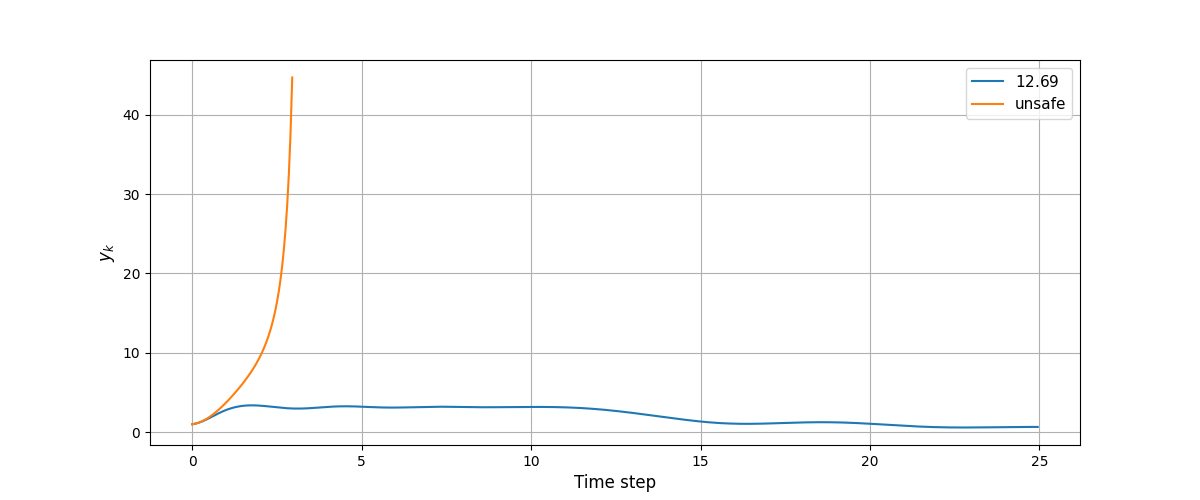

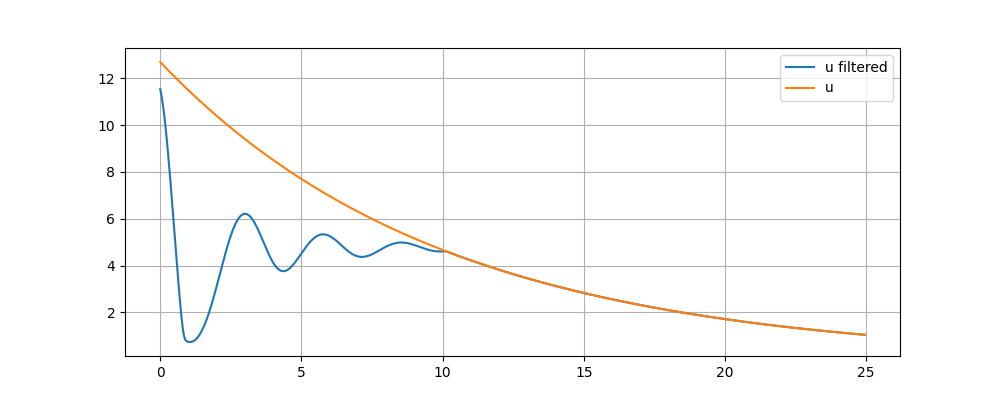

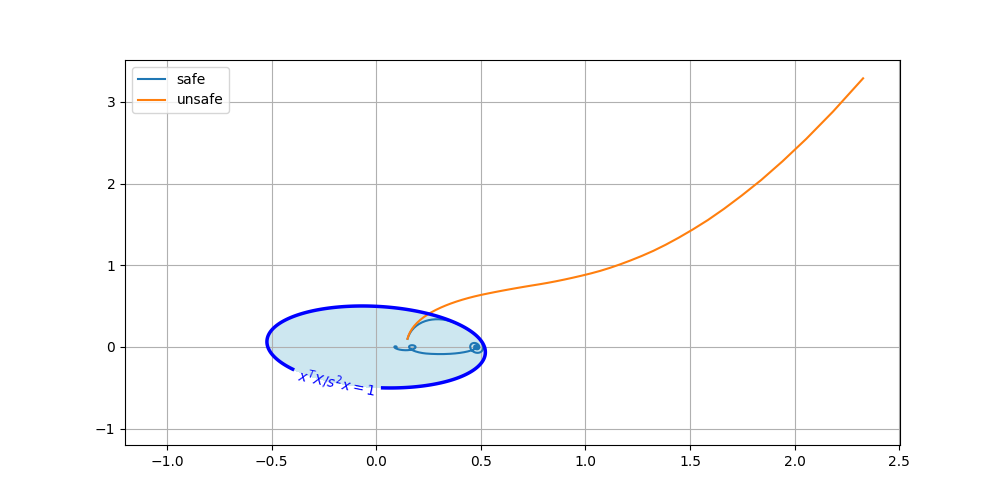

In [25]:
x0 = np.array([0.15,0.1])
u0_max = np.sqrt(s**2 - alpha**2 * x0.reshape(1,-1) @ Pinv @ x0.reshape(-1,1))

N = 500
# _, y_hat, _ = simulate_lure(x0,np.zeros(N))

fig, ax = plt.subplots(figsize=(12,5))
ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('$y_k$', fontsize=12)
ax.grid()
# plot_trajectories(ax, y_hat, label='Zero input')
deltas = [ 1.1*u0_max[0,0]]
for d in deltas:
    print(d)
    xs = np.linspace(0, (N-1)*TS, N)
    u = np.concatenate([np.zeros(0), d*np.exp(-xs*0.1)])

    X_c, y, _, u_true = simulate_lure(x0, u)
    plot_trajectories(ax, y, label=f'${d:.2f}$')

X_d, y_d, _, u_true_d = simulate_lure(x0, u, safety_filter=False)
plot_trajectories(ax, y_d, label=f'unsafe')
plt.show()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(xs, u_true, label='u filtered')
ax.plot(xs, np.array(u), label='u')
ax.legend()
ax.grid()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(X_c[:,0], X_c[:,1], label='safe')
N2 = 50
ax.plot(X_d[:N2,0], X_d[:N2,1], label='unsafe')
ax.legend()
# Plot ellipsoid as filled contour
levels = [0, 1]
contourf = ax.contourf(X1, X2, quad_form, levels=levels, colors=['lightblue'], alpha=0.6)
contour = ax.contour(X1, X2, quad_form, levels=[1], colors=['blue'], linewidths=2.5)
ax.clabel(contour, inline=True, fontsize=10, fmt='$x^T X/s^2 x = 1$')
ax.grid()





In [26]:
# calculate the output reachable set
P = cp.Variable((nx, nx), symmetric=True)
L = cp.Variable((nz, nx))
m = cp.Variable((nz, 1))
M = cp.diag(m)

eps = 1e-6
constraints = []

# stability constraints
F = cp.bmat(
    [
        [-(alpha**2) * P, np.zeros((nx, nd)), P @ C2.T + L.T, P @ A.T],
        [np.zeros((nd, nx)), -np.eye(nd), D21.T, B.T],
        [C2 @ P + L, D21, -2 * M, M @ B2.T],
        [A @ P, B, B2 @ M, -P],
    ]
)
nF = F.shape[0]
constraints.append(F << -eps * np.eye(nF))

# constraints for generalized sector condition
for i in range(nz):
    li = L[i, :].reshape((1, -1), order="C")
    locality_lmi = cp.bmat([[1/s**2, li], [li.T, P]])
    constraints.append(locality_lmi >> eps * np.eye(nx + 1))

# output reachable set constraints
Y_tilde = cp.Variable((ne,ne))
constraints.append(cp.bmat([
    [P/s**2, (C @ P).T], 
    [C @ P, Y_tilde]
]) >> eps * np.eye(nx + ne))
# constraints.append(cp.bmat([
#     [Y_tilde, C @ P, D],
#     [(C@P).T, P/s**2, np.zeros((nx,nd))],
#     [D.T, np.zeros((nd,nx)), 1/(s**2*(1-alpha**2))]
# ]) >> eps * np.eye(nx+ne+nd))

objective = cp.Minimize(cp.norm(Y_tilde))
# objective = cp.Minimize(None)
problem = cp.Problem(objective, constraints )
problem.solve(solver=cp.MOSEK, verbose=False, accept_unknown=True)
print(f'Problem status: {problem.status}')
Y = 1/Y_tilde.value
# print(f'Minimal output reachable set given by E(Y) with Y: {1/Y_tilde.value}')

Problem status: optimal_inaccurate


/Users/jack/Documents/python_venv/genSecSysId/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [27]:
print(f'Max certified output magnitude of \hat y is approximately: {y_std*np.sqrt(1/Y[0,0]):.4f}')

Max certified output magnitude of \hat y is approximately: 0.5693


In [28]:
y_std

0.15781519685820256